# Advanced Player & Team Ratings with SportsQuant

**Three ways to measure player and team strength**

No single rating system captures everything. SportsQuant implements three complementary approaches:
- **RAPTOR** (player): Composite of box score, on-off, and prior components
- **Massey** (team): Linear algebra approach with attack/defense decomposition
- **PageRank** (team): Transitive opponent strength via iterative power method

Each system captures different aspects of strength. Together, they give the fullest picture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sportsquant.models.ratings.raptor_composite import RaptorCompositeFeatures, RaptorCompositeConfig
from sportsquant.models.ratings.massey_ratings import MasseyRatings, MasseyRatingsConfig
from sportsquant.models.ratings.pagerank_ratings import PageRankRatings
from sportsquant.models.ratings.bayesian_priors import (
    BayesianPlayerPrior, PlayerPriorConfig, PlayerPriorRequest, PlayerPosteriorRequest,
)
from sportsquant.models.ratings.bayesian_shrinkage import (
    BayesianFeatureShrinkage, BayesianShrinkageConfig,
    compute_normal_prior, NormalPriorConfig,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Imports successful. Let's rate some players and teams!")

Imports successful. Let's rate some players and teams!


## 1. The Three Rating Systems

| System | Scope | Method | Captures |
|--------|-------|--------|----------|
| **RAPTOR** | Player | Box + On-Off + Priors composite | Individual contribution, team impact |
| **Massey** | Team | Matrix solve M⁻¹p | Point differential, attack/defense split |
| **PageRank** | Team | Power iteration with damping | Quality of opponents beaten |

## 2. Sample Game Data

We create inline game and player data for demonstration.

In [2]:
np.random.seed(42)

# Team game results for Massey and PageRank
teams = ["BOS", "NYK", "MIL", "PHI", "CLE", "DEN", "MIN", "OKC",
          "LAC", "DAL", "PHX", "MIA", "IND", "ORL", "SAC", "LAL"]

# Generate 120 games
n_games = 120
games_data = []
for _ in range(n_games):
    home = np.random.choice(teams)
    away = np.random.choice([t for t in teams if t != home])
    home_score = int(np.random.normal(112, 12))
    away_score = int(np.random.normal(108, 12))
    games_data.append({
        "HOME_TEAM": home, "AWAY_TEAM": away,
        "HOME_SCORE": home_score, "AWAY_SCORE": away_score,
        "WINNER": home if home_score > away_score else away,
        "LOSER": away if home_score > away_score else home,
        "WINNER_SCORE": max(home_score, away_score),
        "LOSER_SCORE": min(home_score, away_score),
    })

games_df = pd.DataFrame(games_data)
print(f"Generated {len(games_df)} games between {len(teams)} teams")
games_df.head()

Generated 120 games between 16 teams


,HOME_TEAM,AWAY_TEAM,HOME_SCORE,AWAY_SCORE,WINNER,LOSER,WINNER_SCORE,LOSER_SCORE
0,MIN,PHI,98,111,PHI,MIN,111,98
1,MIL,OKC,130,117,MIL,OKC,130,117
2,DEN,CLE,105,101,DEN,CLE,105,101
3,CLE,BOS,114,85,CLE,BOS,114,85
4,MIA,LAC,121,89,MIA,LAC,121,89


## 3. Massey Ratings: Attack/Defense Decomposition

The Massey method solves r = M⁻¹p where M is the game margin matrix and p is the point margin vector. It decomposes into offensive and defensive components.

In [3]:
massey = MasseyRatings(home_advantage=3.0)
massey_ratings = massey.compute_ratings(games_df)

# Decompose into offense/defense
massey_ratings[["offensive", "defensive"]] = massey_ratings["overall_rating"].apply(
    lambda r: pd.Series(massey.decompose_rating(r))
)

# Schedule strength
massey_ratings["sos"] = massey_ratings.index.map(
    lambda t: massey.schedule_strength(games_df, t, massey_ratings)
)

massey_ratings = massey_ratings.sort_values("overall_rating", ascending=False)
massey_ratings.style.format({"overall_rating": "{:.2f}", "offensive": "{:.2f}", "defensive": "{:.2f}", "sos": "{:.2f}"})

,overall_rating,offensive,defensive,sos
ORL,6.55,6.55,0.00,1.21
MIA,6.14,6.14,0.00,-0.45
DEN,5.61,5.61,0.00,-0.62
DAL,1.98,1.96,0.02,-0.66
LAL,1.44,1.04,0.40,-0.79
LAC,0.21,0.02,0.19,1.91
MIN,0.16,0.01,0.15,0.98
MIL,-0.06,-0.06,-0.00,-0.33
NYK,-0.48,-0.36,-0.12,-0.06
SAC,-0.75,-0.47,-0.28,0.14


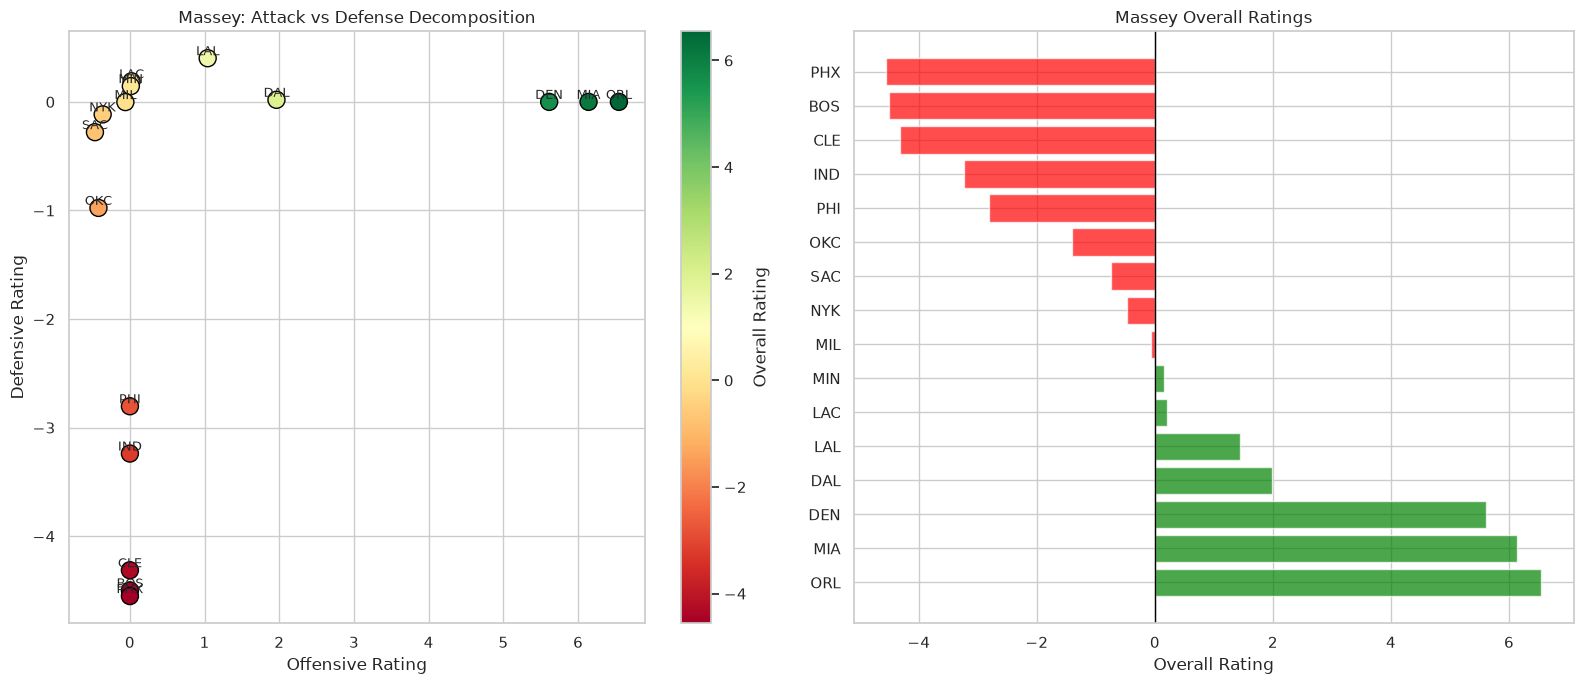

In [4]:
# Visualize Massey ratings decomposition
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Attack/Defense scatter
scatter = axes[0].scatter(
    massey_ratings["offensive"],
    massey_ratings["defensive"],
    c=massey_ratings["overall_rating"],
    cmap="RdYlGn",
    s=150,
    edgecolors="black",
    linewidth=1,
)
for idx in massey_ratings.index:
    axes[0].annotate(idx, (massey_ratings.loc[idx, "offensive"], massey_ratings.loc[idx, "defensive"]),
                     fontsize=9, ha="center", va="bottom")
axes[0].set_xlabel("Offensive Rating")
axes[0].set_ylabel("Defensive Rating")
axes[0].set_title("Massey: Attack vs Defense Decomposition")
plt.colorbar(scatter, ax=axes[0], label="Overall Rating")

# Overall ratings bar chart
colors = ["green" if r > 0 else "red" for r in massey_ratings["overall_rating"]]
axes[1].barh(massey_ratings.index, massey_ratings["overall_rating"], color=colors, alpha=0.7)
axes[1].axvline(x=0, color="black", linewidth=1)
axes[1].set_xlabel("Overall Rating")
axes[1].set_title("Massey Overall Ratings")

plt.tight_layout()
plt.show()

## 4. PageRank Ratings: Transitive Strength

PageRank measures *who you beat*, not just *by how much*. A win over a strong team counts more than a win over a weak team, because strength flows transitively through the graph.

In [5]:
pagerank = PageRankRatings(damping=0.85, max_iterations=100, tolerance=1e-6)
pr_ratings = pagerank.compute_ratings(games_df, teams)

# Sort and display
pr_df = pd.DataFrame({
    "team": list(pr_ratings.keys()),
    "pagerank": list(pr_ratings.values()),
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

pr_df.style.format({"pagerank": "{:.6f}"})

,team,pagerank
0,LAC,0.116729
1,DAL,0.092605
2,ORL,0.092605
3,DEN,0.077252
4,SAC,0.066653
5,NYK,0.066653
6,PHX,0.058906
7,LAL,0.058906
8,MIA,0.053000
9,CLE,0.053000


In [6]:
# Wins against rated opponents for top teams
for team in pr_df["team"].head(5):
    war = pagerank.wins_against_rated(games_df, pr_ratings, team, min_rating_threshold=0.05)
    sos = pagerank.strength_of_schedule(games_df, pr_ratings, team)
    print(f"{team}: PageRank={pr_ratings[team]:.6f}, Wins vs Top={war:.1%}, SOS={sos:.4f}")

LAC: PageRank=0.116729, Wins vs Top=71.4%, SOS=0.0630
DAL: PageRank=0.092605, Wins vs Top=57.1%, SOS=0.0624
ORL: PageRank=0.092605, Wins vs Top=54.5%, SOS=0.0598
DEN: PageRank=0.077252, Wins vs Top=50.0%, SOS=0.0580
SAC: PageRank=0.066653, Wins vs Top=33.3%, SOS=0.0680


## 5. Comparing Massey vs PageRank

Where do the two team rating systems agree? Where do they disagree?

In [7]:
# Merge the two systems
comparison = massey_ratings[["overall_rating"]].copy()
comparison.columns = ["massey"]
comparison["pagerank"] = comparison.index.map(lambda t: pr_ratings.get(t, 0))

# Rank by each system
comparison["massey_rank"] = comparison["massey"].rank(ascending=False)
comparison["pagerank_rank"] = comparison["pagerank"].rank(ascending=False)
comparison["rank_diff"] = comparison["massey_rank"] - comparison["pagerank_rank"]

comparison = comparison.sort_values("massey_rank")
comparison.style.format({"massey": "{:.2f}", "pagerank": "{:.6f}", "massey_rank": "{:.0f}", "pagerank_rank": "{:.0f}", "rank_diff": "{:+.0f}"})

,massey,pagerank,massey_rank,pagerank_rank,rank_diff
ORL,6.55,0.092605,1,2,-2
MIA,6.14,0.053000,2,10,-8
DEN,5.61,0.077252,3,4,-1
DAL,1.98,0.092605,4,2,+2
LAL,1.44,0.058906,5,8,-2
LAC,0.21,0.116729,6,1,+5
MIN,0.16,0.044594,7,14,-6
MIL,-0.06,0.048350,8,12,-4
NYK,-0.48,0.066653,9,6,+4
SAC,-0.75,0.066653,10,6,+4


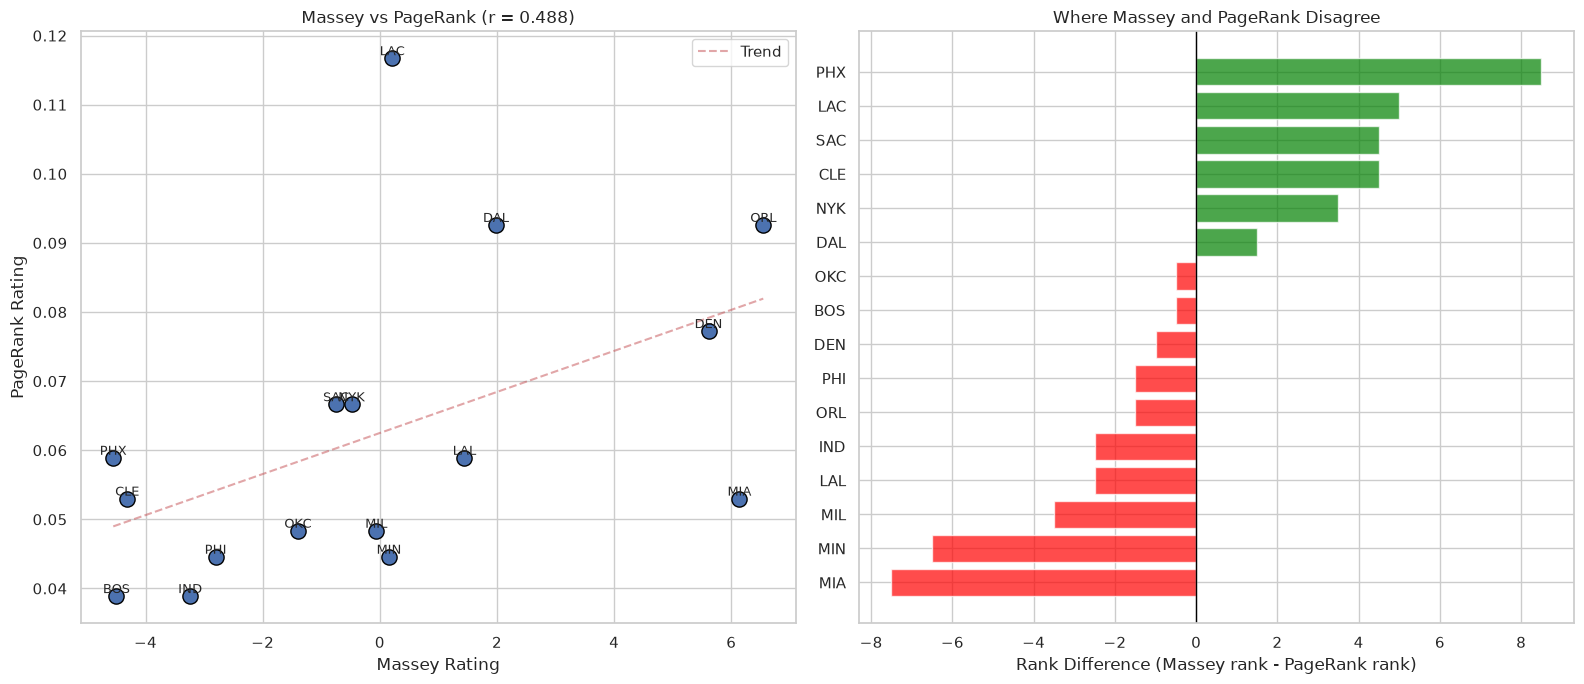

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Massey vs PageRank
axes[0].scatter(comparison["massey"], comparison["pagerank"], s=120, edgecolors="black", linewidth=1)
for idx in comparison.index:
    axes[0].annotate(idx, (comparison.loc[idx, "massey"], comparison.loc[idx, "pagerank"]),
                     fontsize=9, ha="center", va="bottom")
# Add trend line
z = np.polyfit(comparison["massey"], comparison["pagerank"], 1)
p = np.poly1d(z)
x_line = np.linspace(comparison["massey"].min(), comparison["massey"].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.5, label="Trend")
corr = comparison["massey"].corr(comparison["pagerank"])
axes[0].set_xlabel("Massey Rating")
axes[0].set_ylabel("PageRank Rating")
axes[0].set_title(f"Massey vs PageRank (r = {corr:.3f})")
axes[0].legend()

# Rank difference chart
rank_diff = comparison["rank_diff"].sort_values()
colors = ["green" if d > 0 else "red" if d < 0 else "gray" for d in rank_diff]
axes[1].barh(rank_diff.index, rank_diff.values, color=colors, alpha=0.7)
axes[1].axvline(x=0, color="black", linewidth=1)
axes[1].set_xlabel("Rank Difference (Massey rank - PageRank rank)")
axes[1].set_title("Where Massey and PageRank Disagree")

plt.tight_layout()
plt.show()

## 6. Bayesian Player Priors with James-Stein Shrinkage

The `BayesianPlayerPrior` system combines position, experience, and matchup priors. James-Stein shrinkage pulls extreme estimates toward the group mean — especially important for players with limited data.

In [9]:
bayes = BayesianPlayerPrior()

# Compare a rookie vs a veteran
rookie_request = PlayerPriorRequest(
    position="PG",
    years_experience=0,
    stat_type="pts",
    career_avg=0.65,  # Raw career average (high due to small sample)
    opponent_team="BOS",
    historical_vs_opponent=0.60,
)

veteran_request = PlayerPriorRequest(
    position="PG",
    years_experience=10,
    stat_type="pts",
    career_avg=0.55,
    opponent_team="BOS",
    historical_vs_opponent=0.52,
)

rookie_prior = bayes.compute_prior(rookie_request)
veteran_prior = bayes.compute_prior(veteran_request)

print(f"Rookie (0 yrs, PG): prior = {rookie_prior:.4f}, raw career avg = {rookie_request.career_avg:.4f}")
print(f"  Shrinkage toward position average: {rookie_request.career_avg - rookie_prior:.4f}")
print(f"\nVeteran (10 yrs, PG): prior = {veteran_prior:.4f}, raw career avg = {veteran_request.career_avg:.4f}")
print(f"  Shrinkage toward position average: {veteran_request.career_avg - veteran_prior:.4f}")

Rookie (0 yrs, PG): prior = 0.5046, raw career avg = 0.6500
  Shrinkage toward position average: 0.1454

Veteran (10 yrs, PG): prior = 0.4735, raw career avg = 0.5500
  Shrinkage toward position average: 0.0765


In [10]:
# Posterior update with recent data
rookie_posterior_req = PlayerPosteriorRequest(
    prior_request=rookie_request,
    recent_avg=0.70,  # Hot start in 5 games
    n_recent_games=5,
)

veteran_posterior_req = PlayerPosteriorRequest(
    prior_request=veteran_request,
    recent_avg=0.60,  # Decent start in 50 games
    n_recent_games=50,
)

rookie_posterior = bayes.compute_full_posterior(rookie_posterior_req)
veteran_posterior = bayes.compute_full_posterior(veteran_posterior_req)

print(f"\nRookie posterior: {rookie_posterior:.4f} (prior={rookie_prior:.4f}, recent={0.70:.4f} over 5 games)")
print(f"  -> Shrinkage factor for 5 games: {bayes.shrinkage_factor(5):.4f}")
print(f"\nVeteran posterior: {veteran_posterior:.4f} (prior={veteran_prior:.4f}, recent={0.60:.4f} over 50 games)")
print(f"  -> Shrinkage factor for 50 games: {bayes.shrinkage_factor(50):.4f}")


Rookie posterior: 0.6218 (prior=0.5046, recent=0.7000 over 5 games)
  -> Shrinkage factor for 5 games: 0.4000

Veteran posterior: 0.6000 (prior=0.4735, recent=0.6000 over 50 games)
  -> Shrinkage factor for 50 games: 0.0625


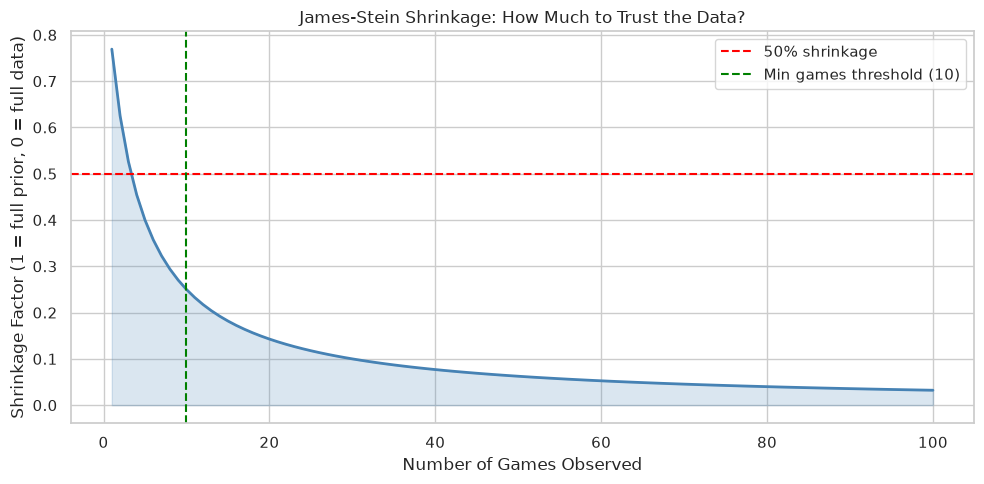

In [11]:
# Visualize shrinkage: how many games to trust data?
n_obs_range = range(1, 101)
shrinkage_factors = [bayes.shrinkage_factor(n) for n in n_obs_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_obs_range), shrinkage_factors, linewidth=2, color="steelblue")
ax.fill_between(list(n_obs_range), 0, shrinkage_factors, alpha=0.2, color="steelblue")
ax.axhline(y=0.5, color="red", linestyle="--", label="50% shrinkage")
ax.axvline(x=10, color="green", linestyle="--", label=f"Min games threshold ({bayes.config.min_games_for_likelihood})")
ax.set_xlabel("Number of Games Observed")
ax.set_ylabel("Shrinkage Factor (1 = full prior, 0 = full data)")
ax.set_title("James-Stein Shrinkage: How Much to Trust the Data?")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Bayesian Feature Shrinkage

For player feature estimation, `BayesianFeatureShrinkage` shrinks extreme features toward league averages using a Normal-Normal model.

In [12]:
# Demonstrate Normal prior shrinkage for different sample sizes
config = NormalPriorConfig(prior_mean=0.0, prior_std=1.0, shrinkage_factor=0.3)

sample_mean = 2.5  # Observed mean above league average
sample_std = 3.0

shrinkage_results = []
for n in [5, 10, 20, 50, 100, 200]:
    posterior = compute_normal_prior(sample_mean, sample_std, n, config)
    weight_on_data = min(1.0, n / 50.0)
    shrinkage_results.append({
        "n_games": n,
        "sample_mean": sample_mean,
        "posterior_mean": posterior,
        "shrinkage": sample_mean - posterior,
        "weight_on_data": weight_on_data,
    })

shrink_df = pd.DataFrame(shrinkage_results)
shrink_df.style.format({"sample_mean": "{:.2f}", "posterior_mean": "{:.4f}", "shrinkage": "{:.4f}", "weight_on_data": "{:.2f}"})

,n_games,sample_mean,posterior_mean,shrinkage,weight_on_data
0,5,2.50,0.3571,2.1429,0.10
1,10,2.50,0.6250,1.8750,0.20
2,20,2.50,1.0000,1.5000,0.40
3,50,2.50,1.5625,0.9375,1.00
4,100,2.50,1.9231,0.5769,1.00
5,200,2.50,2.1739,0.3261,1.00


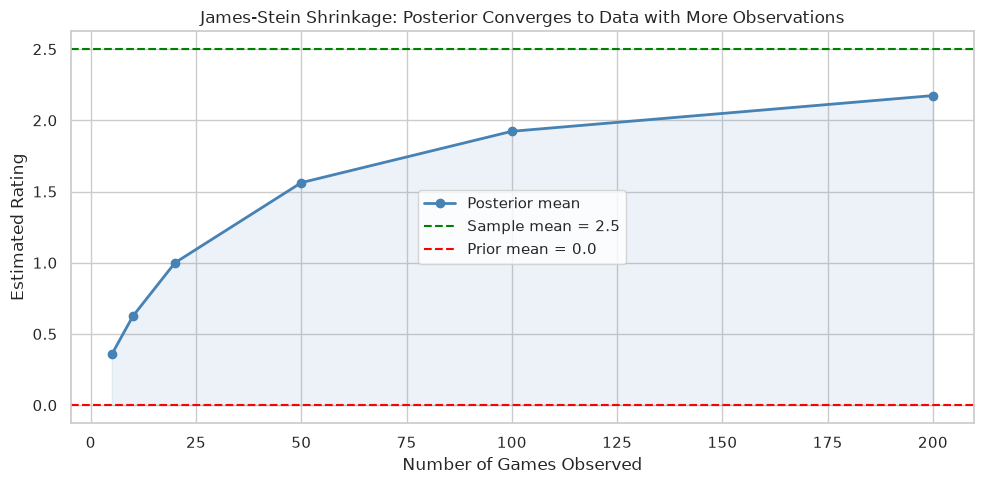

In [13]:
# Visualize: Posterior mean vs sample size
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(shrink_df["n_games"], shrink_df["posterior_mean"], "o-", linewidth=2, color="steelblue", label="Posterior mean")
ax.axhline(y=sample_mean, color="green", linestyle="--", label=f"Sample mean = {sample_mean}")
ax.axhline(y=config.prior_mean, color="red", linestyle="--", label=f"Prior mean = {config.prior_mean}")
ax.fill_between(shrink_df["n_games"], config.prior_mean, shrink_df["posterior_mean"], alpha=0.1, color="steelblue")
ax.set_xlabel("Number of Games Observed")
ax.set_ylabel("Estimated Rating")
ax.set_title("James-Stein Shrinkage: Posterior Converges to Data with More Observations")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Position Priors: What's Normal for Each Position?

The `PositionPriorGenerator` provides baseline probabilities by position, which serve as priors for new or low-sample players.

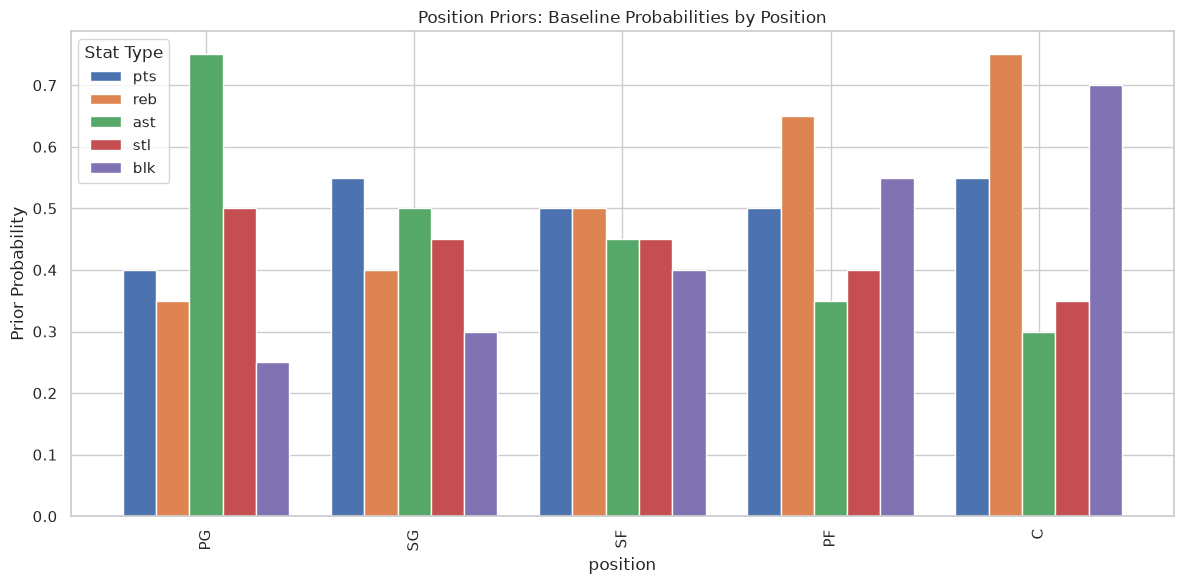

In [14]:
from sportsquant.models.ratings.bayesian_priors import PositionPriorGenerator

pos_gen = PositionPriorGenerator()
positions = pos_gen.get_default_positions()
stats = ["pts", "reb", "ast", "stl", "blk"]

pos_prior_data = []
for pos in positions:
    row = {"position": pos}
    for stat in stats:
        row[stat] = pos_gen.get_position_prior(pos, stat)
    pos_prior_data.append(row)

pos_df = pd.DataFrame(pos_prior_data).set_index("position")

fig, ax = plt.subplots(figsize=(12, 6))
pos_df.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Prior Probability")
ax.set_title("Position Priors: Baseline Probabilities by Position")
ax.legend(title="Stat Type")
plt.tight_layout()
plt.show()

## Key Takeaway

> **Different rating systems capture different aspects of strength; combining them gives the fullest picture.**

1. **Massey** captures point differential and decomposes into offense/defense — great for spread modeling
2. **PageRank** captures transitive strength (who beat whom) — reveals teams that beat good opponents
3. **RAPTOR** combines box score, on-off, and priors for player-level ratings
4. **BayesianPlayerPrior** applies James-Stein shrinkage: rookies shrink toward position averages, veterans stay data-driven
5. Always compare ratings across systems — disagreement signals something interesting
6. Use `shrinkage_factor()` to decide how much to trust limited data